# Investigate and Stress-Test Fraud Scenarios

A good model score on one dataset is not enough. This tutorial stress-tests the evidence around a fraud model: replayed events, coordinated networks, subtle behavior, and realistic what-if cases. FraudTwin gives us controlled experiments where we know exactly what changed.

## 1. Set up the investigation

We use versioned benchmark configurations rather than hand-made examples. FraudTwin records the seed, configuration, and output fingerprints so another engineer can repeat the investigation later.

This notebook tests scenario behavior and data lineage. These generated runs use delayed labels, so it intentionally does not claim a model-quality score; use the ML tutorials once labels have matured.

The figures use Matplotlib. If it is missing from the notebook kernel, run `%pip install matplotlib` once and rerun the cells.

In [1]:
from datetime import timedelta
from pathlib import Path
from tempfile import TemporaryDirectory

import polars as pl

import fraudtwin
from fraudtwin.config import load_config
from fraudtwin.graph import build_graph
from fraudtwin.replay import replay_run

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

project_root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "configs" / "minimal-v1.yaml").is_file()
)
config_dir = project_root / "configs" / "benchmarks"
graph_config = load_config(config_dir / "camouflage-v1.yaml")
difficulty_config = load_config(config_dir / "difficulty-v1.yaml")
counterfactual_config = load_config(config_dir / "counterfactual-v1.yaml")

## 2. Establish a fraud baseline

First we create the reference world: ordinary payments plus known fraud campaigns. This control group lets us tell whether a later stress test changed the challenge or the whole dataset.

In [2]:
baseline = fraudtwin.generate(graph_config)
baseline_summary = pl.DataFrame(
    {
        "Run": [baseline.run_id],
        "Payments": [len(baseline.behavior.payments)],
        "Fraud records": [len(baseline.behavior.fraud_records)],
    }
)
display(baseline_summary)

Run,Payments,Fraud records
str,i64,i64
"""RUN-3c8a07d6ac6d0773""",949,108


## 3. Replay the incident

Replay answers, 'What did the system see during the first six hours?' It preserves event identity and ordering instead of generating a new story. The temporary directory is only the notebook's local run archive.

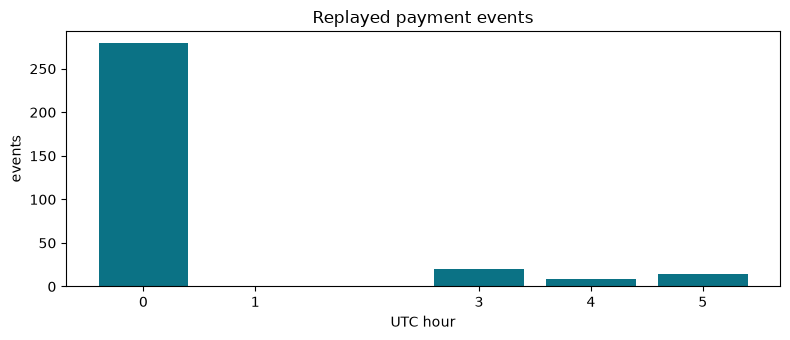

replay_sequence,event_type,payment_id,event_time
i64,str,str,"datetime[μs, UTC]"
1,"""PIX_INITIATED""","""PAY-F04-000004-000001""",2026-01-01 00:00:00 UTC
2,"""CARD_PAYMENT_INITIATED""","""PAY-HN-F01-000001-000001""",2026-01-01 00:00:00 UTC
3,"""CARD_PAYMENT_INITIATED""","""PAY-HN-F02-000002-000001""",2026-01-01 00:00:00 UTC
4,"""FRAUD_AUTHENTICATION_SUSPICIOU…","""PAY-HN-F03-000003-000001""",2026-01-01 00:00:00 UTC
5,"""PIX_INITIATED""","""PAY-HN-F04-000004-000001""",2026-01-01 00:00:00 UTC
6,"""CARD_PAYMENT_INITIATED""","""PAY-HN-F05-000005-000001""",2026-01-01 00:00:00 UTC


In [3]:
with TemporaryDirectory(prefix="fraudtwin-investigation-") as output_dir:
    written = fraudtwin.generate(graph_config, write=True, output_dir=output_dir)
    replay = replay_run(
        written.run_dir,
        graph_config.simulation.start,
        graph_config.simulation.start + timedelta(hours=6),
    )
    replay_by_hour = (
        replay.frame.with_columns(pl.col("event_time").dt.hour().alias("hour"))
        .group_by("hour")
        .len(name="events")
        .sort("hour")
    )

if plt is not None:
    fig, axis = plt.subplots(figsize=(8, 3.5))
    axis.bar(replay_by_hour["hour"].to_list(), replay_by_hour["events"].to_list(), color="#0b7285")
    axis.set(title="Replayed payment events", xlabel="UTC hour", ylabel="events")
    axis.set_xticks(replay_by_hour["hour"].to_list())
    fig.tight_layout()
    plt.show()
    plt.close(fig)
display(replay.frame.select(["replay_sequence", "event_type", "payment_id", "event_time"]).head(6))

## 4. Measure the fraud graph

Some fraud is not suspicious in one payment but becomes suspicious as a relationship pattern. Compare the observable graph available to a detector with the oracle graph containing the simulator's complete campaign truth.

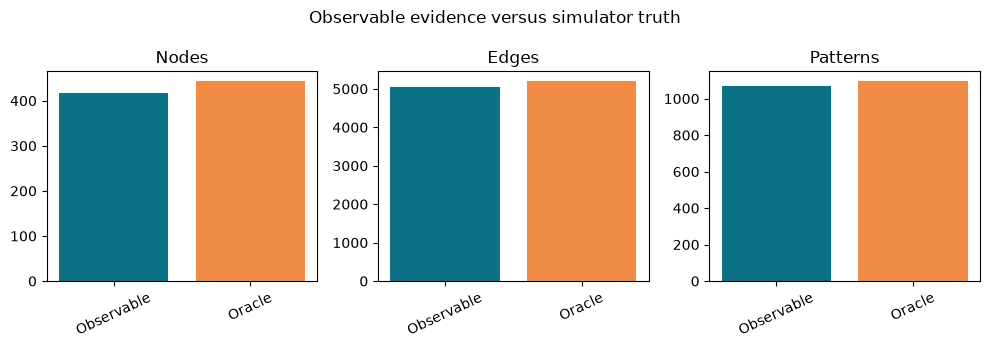

In [4]:
observable = build_graph(
    graph_config, baseline.entities, baseline.behavior, baseline.manifest, view="observable"
)
oracle = build_graph(
    graph_config, baseline.entities, baseline.behavior, baseline.manifest, view="oracle"
)
graph_metrics = pl.DataFrame(
    {
        "View": ["Observable", "Oracle"],
        "Nodes": [len(observable.nodes), len(oracle.nodes)],
        "Edges": [len(observable.edges), len(oracle.edges)],
        "Patterns": [len(observable.patterns), len(oracle.patterns)],
    }
)
if plt is not None:
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    for axis, metric in zip(axes, ("Nodes", "Edges", "Patterns"), strict=False):
        axis.bar(
            graph_metrics["View"].to_list(),
            graph_metrics[metric].to_list(),
            color=["#0b7285", "#f08c46"],
        )
        axis.set_title(metric)
        axis.tick_params(axis="x", rotation=25)
    fig.suptitle("Observable evidence versus simulator truth")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 5. Make fraud harder to recognize

If a detector succeeds only because fraud is extreme, it is not ready for production. The difficulty profile makes fraud more similar to legitimate behavior while keeping the underlying fraud objective intact.

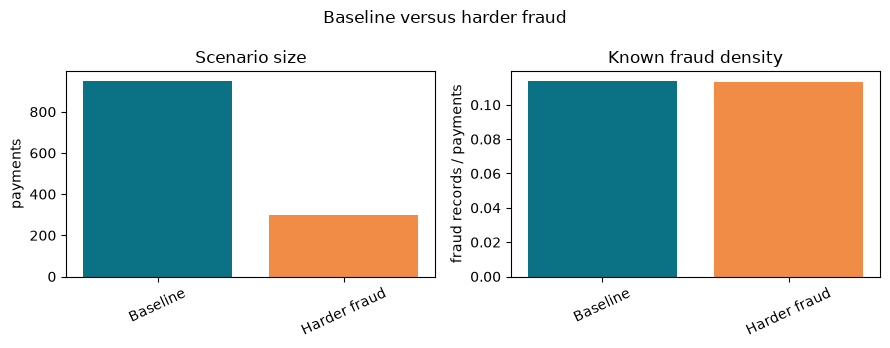

In [5]:
harder = fraudtwin.generate(difficulty_config)
difficulty = harder.manifest.difficulty
scenario_metrics = pl.DataFrame(
    {
        "Scenario": ["Baseline", "Harder fraud"],
        "Payments": [len(baseline.behavior.payments), len(harder.behavior.payments)],
        "Fraud records": [len(baseline.behavior.fraud_records), len(harder.behavior.fraud_records)],
        "Difficulty": [
            "camouflage",
            str(difficulty["requested_difficulty"]) if difficulty else "none",
        ],
    }
).with_columns((pl.col("Fraud records") / pl.col("Payments")).alias("Fraud rate"))
labels = scenario_metrics["Scenario"].to_list()
if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].bar(labels, scenario_metrics["Payments"].to_list(), color=["#0b7285", "#f08c46"])
    axes[0].set(title="Scenario size", ylabel="payments")
    axes[1].bar(labels, scenario_metrics["Fraud rate"].to_list(), color=["#0b7285", "#f08c46"])
    axes[1].set(title="Known fraud density", ylabel="fraud records / payments")
    for axis in axes:
        axis.tick_params(axis="x", rotation=25)
    fig.suptitle("Baseline versus harder fraud")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 6. Add feature and relation camouflage

Difficulty changes how subtle the fraud is; camouflage changes what it resembles. The manifest records the exact strength used for amounts, timing, devices, and relationships.

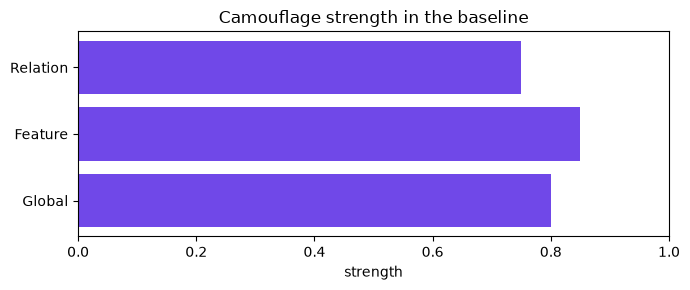

In [6]:
camouflage = baseline.manifest.camouflage
camouflage_metrics = pl.DataFrame(
    {
        "Setting": ["Global", "Feature", "Relation"],
        "Strength": [
            camouflage["resolved_global"]["camouflage"],
            camouflage["resolved_global"]["feature"],
            camouflage["resolved_global"]["relation"],
        ],
    }
)
if plt is not None:
    fig, axis = plt.subplots(figsize=(7, 3))
    axis.barh(
        camouflage_metrics["Setting"].to_list(),
        camouflage_metrics["Strength"].to_list(),
        color="#7048e8",
    )
    axis.set(title="Camouflage strength in the baseline", xlabel="strength", xlim=(0, 1))
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 7. Ask a counterfactual question

What small change could turn a legitimate payment trajectory into a selected fraud pattern? Counterfactuals answer that question and keep links to the original payment, events, and ledger records.

In [7]:
counterfactual_run = fraudtwin.generate(counterfactual_config)
counterfactual = counterfactual_run.behavior.counterfactual
counterfactual_table = pl.DataFrame(
    [
        {
            "Objective": change.objective,
            "Status": change.status,
            "Source payment": change.source_payment_id,
            "Derived payment": change.derived_payment_id,
            "Distance": change.effective_distance,
            "Changed dimensions": len(change.changed_fields),
        }
        for change in counterfactual.change_sets
    ]
)
display(counterfactual_table)

Objective,Status,Source payment,Derived payment,Distance,Changed dimensions
str,str,str,str,f64,i64
"""F01""","""ACCEPTED""","""PAY-00000670""","""CF-PAY-ae3db91708dcf93fd927""",1.0,1
"""F03""","""ACCEPTED""","""PAY-00000434""","""CF-PAY-0267e083b9c5f414158e""",1.0,1
"""F04""","""ACCEPTED""","""PAY-00000155""","""CF-PAY-7df8b9e1c7893631bd62""",1.0,1


## 8. Summarize the evidence

The investigation ends with evidence, not one magic metric. Each run remains connected to payments, events, graph relationships, and fraud objectives. The label check is important: unresolved labels are expected in this forward-looking simulation, so model metrics belong in a later, matured-label evaluation.

In [8]:
baseline_rows = baseline.require_dataset().rows
harder_rows = harder.require_dataset().rows
label_status = pl.DataFrame(
    {
        "Dataset": ["Baseline", "Harder fraud"],
        "Rows": [len(baseline_rows), len(harder_rows)],
        "Mature labels": [
            sum(row.get("label") is not None for row in baseline_rows),
            sum(row.get("label") is not None for row in harder_rows),
        ],
        "Policy": ["wait for maturity", "wait for maturity"],
    }
)
evidence_table = pl.DataFrame(
    {
        "Evidence": [
            "Baseline payments",
            "Harder-fraud payments",
            "Observable graph edges",
            "Oracle graph edges",
            "Accepted counterfactuals",
        ],
        "Value": [
            len(baseline.behavior.payments),
            len(harder.behavior.payments),
            len(observable.edges),
            len(oracle.edges),
            sum(change.status == "ACCEPTED" for change in counterfactual.change_sets),
        ],
    }
)
display(evidence_table)
display(label_status)

Evidence,Value
str,i64
"""Baseline payments""",949
"""Harder-fraud payments""",300
"""Observable graph edges""",5045
"""Oracle graph edges""",5196
"""Accepted counterfactuals""",3


Dataset,Rows,Mature labels,Policy
str,i64,i64,str
"""Baseline""",913,0,"""wait for maturity"""
"""Harder fraud""",288,0,"""wait for maturity"""


## References and implementation notes

- [Fraud Detection Handbook - simulated datasets](https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_3_GettingStarted/SimulatedDataset.html) - scenario-based fraud generation.
- [Fraud Detection Handbook - validation strategies](https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_5_ModelValidationAndSelection/ValidationStrategies.html) - temporal replay and delayed-label evaluation.
- [Feast - point-in-time joins](https://docs.feast.dev/getting-started/concepts/point-in-time-joins) - event, feature, and label availability.
- [IBM AMLSim](https://github.com/IBM/AMLSim) - synthetic banking networks and fraud relationships.
- [Mothilal, Sharma, and Tan - counterfactual explanations](https://doi.org/10.1145/3351095.3372850) - minimum-change counterfactuals.

These are design references, not copied datasets or implementations.

## Tutorial contract

The assertions below keep the tutorial executable while the figures and compact tables keep its outputs readable.

In [9]:
assert baseline_summary["Payments"][0] > 0
assert graph_metrics.height == 2
assert scenario_metrics.height == 2
display(
    pl.DataFrame(
        {
            "Check": ["baseline generated", "replay captured events", "stress scenario generated"],
            "Result": ["ok", f"{replay.count:,} events", "ok"],
        }
    )
)

Check,Result
str,str
"""baseline generated""","""ok"""
"""replay captured events""","""323 events"""
"""stress scenario generated""","""ok"""


In [10]:
assert label_status["Mature labels"].sum() == 0